In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

wavelengths = np.linspace(400, 700, 100)

def gold_spectrum(diameter):
    peak = 520 + diameter * 0.8
    width = 60 + diameter * 0.3
    ext = np.exp(-((wavelengths - peak)**2) / (width**2))
    noise = np.random.normal(0, 0.02, 100)
    return ext + noise

def silver_spectrum(diameter):
    peak = 420 + diameter * 0.5
    width = 40 + diameter * 0.2
    ext = np.exp(-((wavelengths - peak)**2) / (width**2))
    noise = np.random.normal(0, 0.02, 100)
    return ext + noise

X = []
y = []

for d in np.random.uniform(20, 100, 50):
    X.append(gold_spectrum(d))
    y.append(0)

for d in np.random.uniform(20, 100, 50):
    X.append(silver_spectrum(d))
    y.append(1)

X = np.array(X)
y = np.array(y)

print(f"Dataset ready: {X.shape}")

Dataset ready: (100, 100)


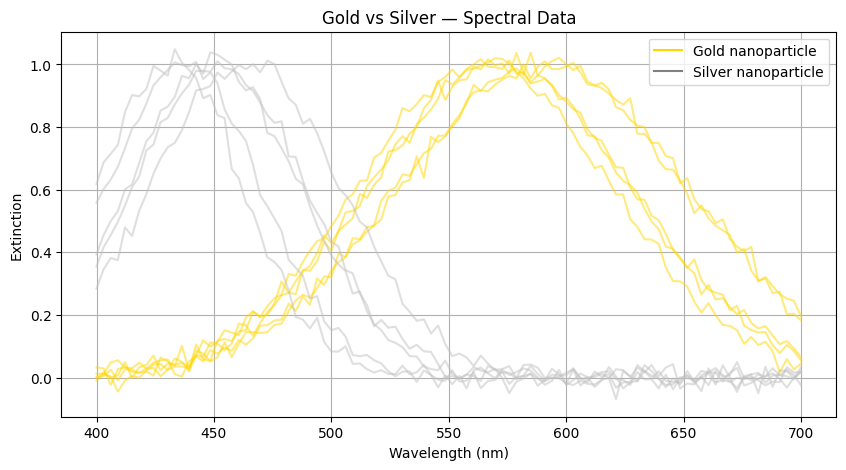

In [11]:
# Data visualize করো
plt.figure(figsize=(10, 5))

# কয়েকটা Gold spectrum
for i in range(5):
    plt.plot(wavelengths, X[i], 'gold', alpha=0.5)

# কয়েকটা Silver spectrum  
for i in range(50, 55):
    plt.plot(wavelengths, X[i], 'silver', alpha=0.5)

plt.plot([], [], 'gold', label='Gold nanoparticle')
plt.plot([], [], 'gray', label='Silver nanoparticle')
plt.title("Gold vs Silver — Spectral Data")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Extinction")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training: {X_train.shape}")
print(f"Testing: {X_test.shape}")

# Model train করো
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict করো
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy * 100:.1f}%")

Training: (80, 100)
Testing: (20, 100)

Accuracy: 100.0%


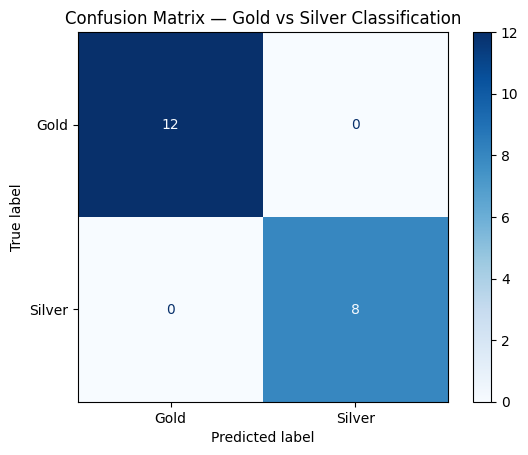


Detailed Report:
              precision    recall  f1-score   support

        Gold       1.00      1.00      1.00        12
      Silver       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Gold', 'Silver']
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Gold vs Silver Classification")
plt.show()

print("\nDetailed Report:")
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, 
      target_names=['Gold', 'Silver']))